# Prompt Versioning with LangGraph

## Folder structure
```
prompts/
  v1.json   ← basic: short, direct answers
  v2.json   ← detailed: structured with explanation
  v3.json   ← expert: deep technical with trade-offs
```

## How it works
```
user_input + version_name
  → load_prompt   (reads the right .json file from disk)
  → run_prompt    (calls gpt-4o with that prompt)
  → response
```

Swapping versions = swapping one filename. No code changes needed.

In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Folder where all prompt JSON files live
PROMPTS_DIR = "prompts"

In [2]:
# ── State ─────────────────────────────────────────────────
class PromptState(TypedDict):
    user_input:    str             # The question to answer
    version:       str             # Which prompt version to use: v1 / v2 / v3
    prompt_data:   Optional[dict]  # Loaded JSON content
    response:      Optional[str]   # LLM response

In [3]:
# ── Node 1: load_prompt ───────────────────────────────────
# Reads the correct .json file from the prompts/ folder.
# The version name maps directly to a filename: v1 → prompts/v1.json

def load_prompt(state: PromptState) -> PromptState:
    version  = state["version"]
    filepath = os.path.join(PROMPTS_DIR, f"{version}.json")

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Prompt file not found: {filepath}\n"
            f"Available versions: {os.listdir(PROMPTS_DIR)}"
        )

    with open(filepath) as f:
        data = json.load(f)

    print(f"[load_prompt] Loaded: {filepath}")
    print(f"  version     : {data['version']}")
    print(f"  description : {data['description']}")
    return {**state, "prompt_data": data}

In [4]:
# ── Node 2: run_prompt ────────────────────────────────────
# Uses the loaded prompt data to configure and call the LLM.
# Temperature and max_tokens come from the JSON file — not hardcoded.

def run_prompt(state: PromptState) -> PromptState:
    data = state["prompt_data"]

    llm = ChatOpenAI(
        model       = "gpt-4o",
        temperature = data.get("temperature", 0.3),
        max_tokens  = data.get("max_tokens",  300),
    )

    print(f"[run_prompt] Calling LLM with version {data['version']}...")

    response = llm.invoke([
        SystemMessage(content=data["system"]),
        HumanMessage(content=state["user_input"])
    ])

    return {**state, "response": response.content.strip()}

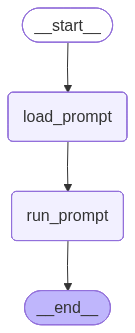

In [5]:
# ── Graph Construction ─────────────────────────────────────
def build_graph():
    builder = StateGraph(PromptState)

    builder.add_node("load_prompt", load_prompt)
    builder.add_node("run_prompt",  run_prompt)

    builder.add_edge(START,         "load_prompt")
    builder.add_edge("load_prompt", "run_prompt")
    builder.add_edge("run_prompt",  END)

    return builder.compile()


graph = build_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# ── Helper ────────────────────────────────────────────────
def ask(question: str, version: str) -> str:
    result = graph.invoke({
        "user_input":  question,
        "version":     version,
        "prompt_data": None,
        "response":    None,
    })
    return result["response"]

In [7]:
# ── Run: same question, three versions ────────────────────
QUESTION = "What is a large language model?"

for version in ["v1", "v2", "v3"]:
    print(f"\n{'='*60}")
    print(f"VERSION: {version}")
    print('='*60)
    answer = ask(QUESTION, version)
    print(answer)


VERSION: v1
[load_prompt] Loaded: prompts\v1.json
  version     : v1
  description : Basic prompt â€” short, direct answers
[run_prompt] Calling LLM with version v1...
A large language model is an advanced artificial intelligence system designed to understand, generate, and manipulate human language, typically trained on vast amounts of text data to perform tasks such as translation, summarization, and conversation.

VERSION: v2
[load_prompt] Loaded: prompts\v2.json
  version     : v2
  description : Detailed prompt â€” structured answers with explanation
[run_prompt] Calling LLM with version v2...
1. A large language model (LLM) is an artificial intelligence model designed to understand and generate human-like text by predicting the next word in a sequence based on the context provided.

2. Large language models are trained on vast amounts of text data and use deep learning techniques, particularly neural networks, to learn patterns in language. They can perform a variety of tasks su

In [8]:
# ── Inspect what is inside each JSON file ─────────────────
for fname in sorted(os.listdir(PROMPTS_DIR)):
    if fname.endswith(".json"):
        with open(os.path.join(PROMPTS_DIR, fname)) as f:
            data = json.load(f)
        print(f"--- {fname} ---")
        print(f"  version     : {data['version']}")
        print(f"  description : {data['description']}")
        print(f"  temperature : {data['temperature']}")
        print(f"  max_tokens  : {data['max_tokens']}")
        print()

--- v1.json ---
  version     : v1
  description : Basic prompt â€” short, direct answers
  temperature : 0.3
  max_tokens  : 100

--- v2.json ---
  version     : v2
  description : Detailed prompt â€” structured answers with explanation
  temperature : 0.4
  max_tokens  : 300

--- v3.json ---
  version     : v3
  description : Expert prompt â€” deep technical answers with nuance
  temperature : 0.2
  max_tokens  : 600



## JSON file structure

Each prompt version is a self-contained `.json` file:

```json
{
  "version":     "v1",
  "description": "Basic prompt — short, direct answers",
  "system":      "You are a helpful assistant...",
  "temperature": 0.3,
  "max_tokens":  100
}
```

## How to add a new version

1. Create `prompts/v4.json` with your new system prompt
2. Call `ask(question, "v4")` — no code changes needed

## What each version does

| File | Style | Temperature | Max tokens |
|---|---|---|---|
| `v1.json` | Basic — 1-2 sentences | 0.3 | 100 |
| `v2.json` | Detailed — direct answer + explanation + example | 0.4 | 300 |
| `v3.json` | Expert — definition + mechanism + trade-offs + example | 0.2 | 600 |